# Project Name
Employee Attrition Prediction — Machine Learning Project

# Project Summary
This project aims to predict whether an employee will leave the company (attrition) using various HR factors.

The goal is to identify major drivers of attrition and help the organization take actions to improveemployee retention.

The project includes data exploration, preprocessing, feature engineering,model building, hyperparameter tuning, evaluation, and insights.


# About the Dataset

**Dataset**: WA_Fn-UseC_-HR-Employee-Attrition.csv (IBM HR Employee Attrition Dataset)
This dataset contains employee information across multiple HR-related variables. 

Below are the key columns exactly as present in your dataset:
### • Age — Employee age
### • Attrition — Whether employee left the company (Yes/No)
### • BusinessTravel — Frequency of business travel
### • DailyRate — Employee's daily salary rate
### • Department — Department of the employee
### • DistanceFromHome — Distance between home and workplace
### • Education — Education level (1–5)
### • EducationField — Field of education
### • EmployeeNumber — Unique employee ID
### • EnvironmentSatisfaction — Satisfaction with work environment
### • Gender — Male/Female
### • HourlyRate — Hourly salary rate
### • JobInvolvement — Level of job involvement
### • JobLevel — Level of the job position
### • JobRole — Role title (e.g., Sales Executive)
### • JobSatisfaction — Employee job satisfaction (1–4)
### • MaritalStatus — Marital status of employee
### • MonthlyIncome — Monthly salary
### • MonthlyRate — Monthly income rate
### • NumCompaniesWorked — Number of companies the employee has worked for
### • Over18 — Whether age is above 18
### • OverTime — Whether employee does overtime
### • PercentSalaryHike — Percent salary increase
### • PerformanceRating — Performance score
### • RelationshipSatisfaction — Relationship satisfaction score
### • StandardHours — Standard working hours
### • StockOptionLevel — Stock option level
### • TotalWorkingYears — Total years of work experience
### • TrainingTimesLastYear — Number of trainings attended last year
### • WorkLifeBalance — Work-life balance rating
### • YearsAtCompany — Number of years at company
### • YearsInCurrentRole — Number of years in current role
### • YearsSinceLastPromotion — Years since last promotion
### • YearsWithCurrManager — Years with current manager


**Purpose**: Predict employee attrition and find key drivers influencing employee exit.

**Dataset Source**: IBM HR Analytics Employee Attrition Dataset (commonly used for HR analytics projects)

**Details**:

• **Rows**: ~1470

• **Target Column**: Attrition (Yes/No)

• **Features include**:
- Demographics (Age, Gender, MaritalStatus)
- Job-related factors (JobRole, Department, JobLevel)
- Work environment (WorkLifeBalance, JobSatisfaction)
- Compensation (MonthlyIncome, PercentSalaryHike)
- Overtime and business travel


**Purpose**: Use HR data to build predictive models that identify employees at risk of leaving.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib


# For reproducibility
RANDOM_STATE = 42

In [10]:
df = pd.read_csv(r"C:\Users\admin\Downloads\employe_attrition.csv")
print('Dataset loaded — shape:', df.shape)


df.head()

Dataset loaded — shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
print('\n--- Info ---')
df.info()


print('\n--- Missing values per column ---')
print(df.isnull().sum().sort_values(ascending=False).head(20))


print('\n--- Basic stats for numeric columns ---')
print(df.describe().T)


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

In [13]:
# Common IBM HR dataset uses column 'Attrition' with values 'Yes'/'No'
if 'Attrition' in df.columns:
    print('\nValue counts for Attrition:')
    print(df['Attrition'].value_counts())
else:
    print("Target column 'Attrition' not found — please check dataset and rename the target column to 'Attrition'.")


Value counts for Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


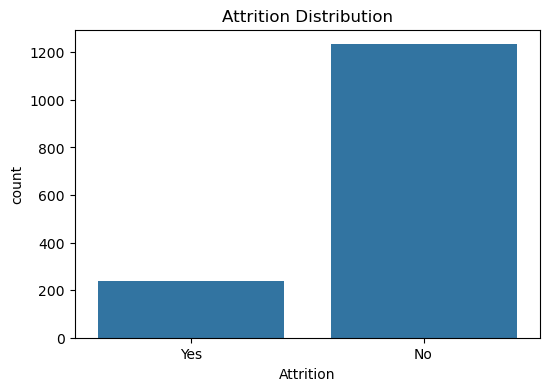

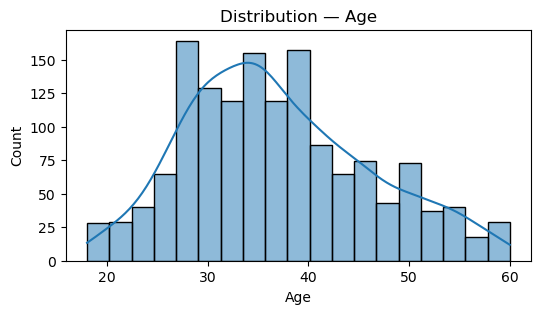

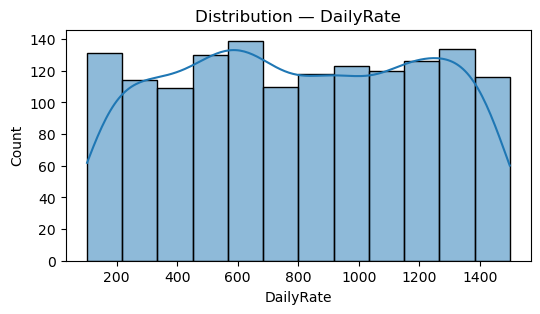

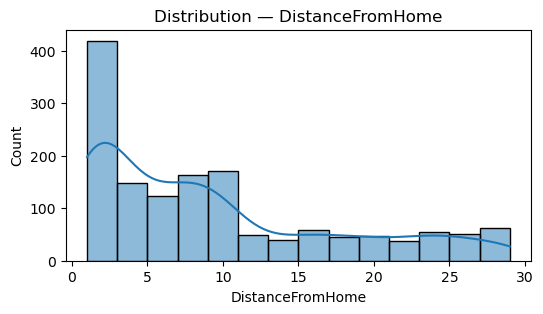

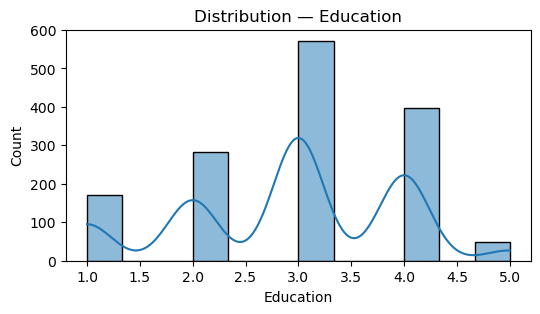

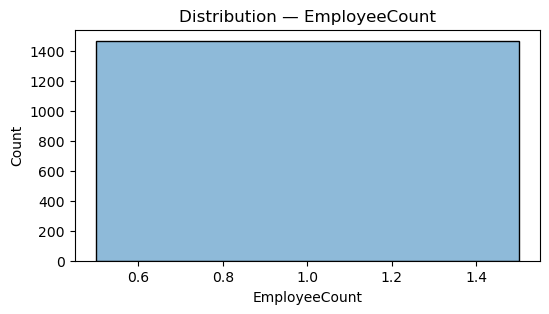

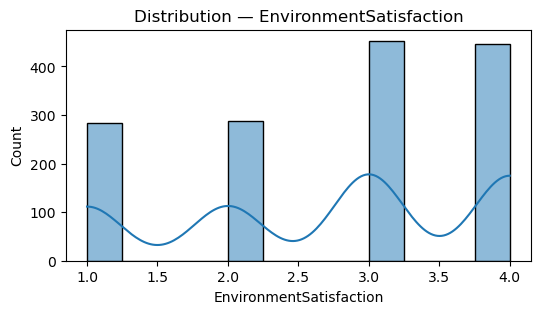

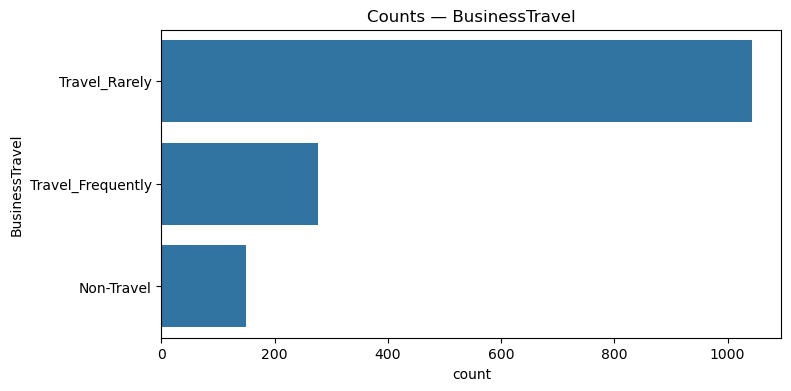

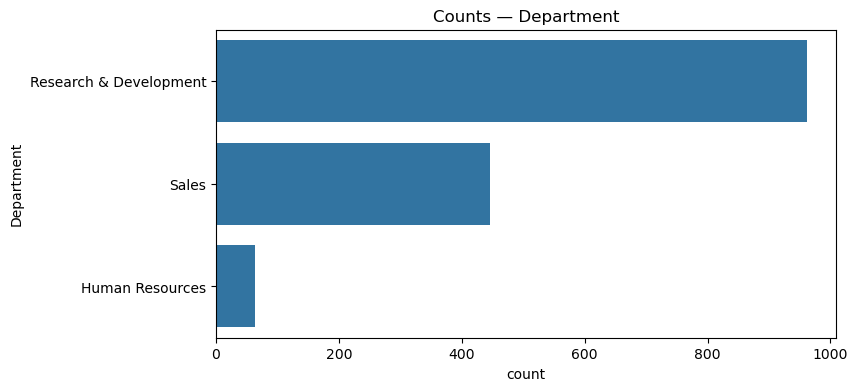

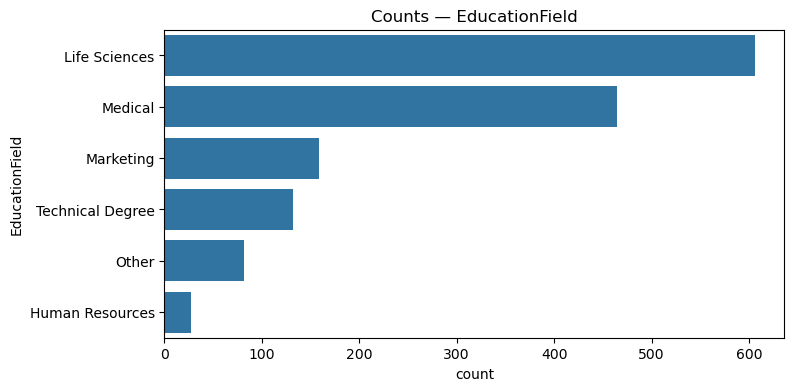

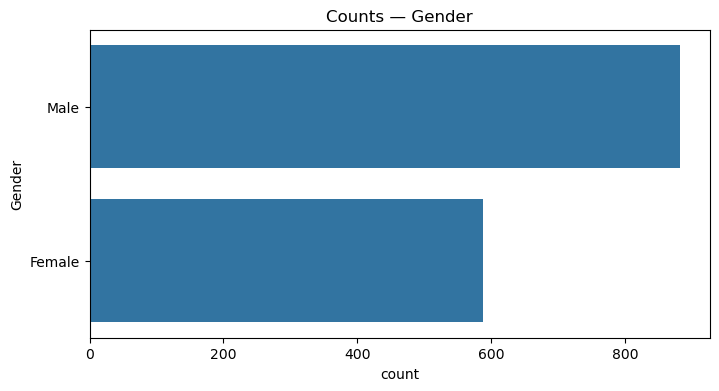

In [15]:
# Basic EDA visualizations
# -----------------------------
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()


# Numeric distributions (select a few important numeric cols if dataset large)
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'EmployeeNumber'][:6] # pick up to 6 for quick view


for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution — {col}')
    plt.show()


# Categorical plots (example: JobRole, MaritalStatus)
cat_example = [c for c in df.select_dtypes(include=['object']).columns if c != 'Attrition'][:4]
for c in cat_example:
    plt.figure(figsize=(8,4))
    sns.countplot(y=c, data=df, order=df[c].value_counts().index)
    plt.title(f'Counts — {c}')
    plt.show()

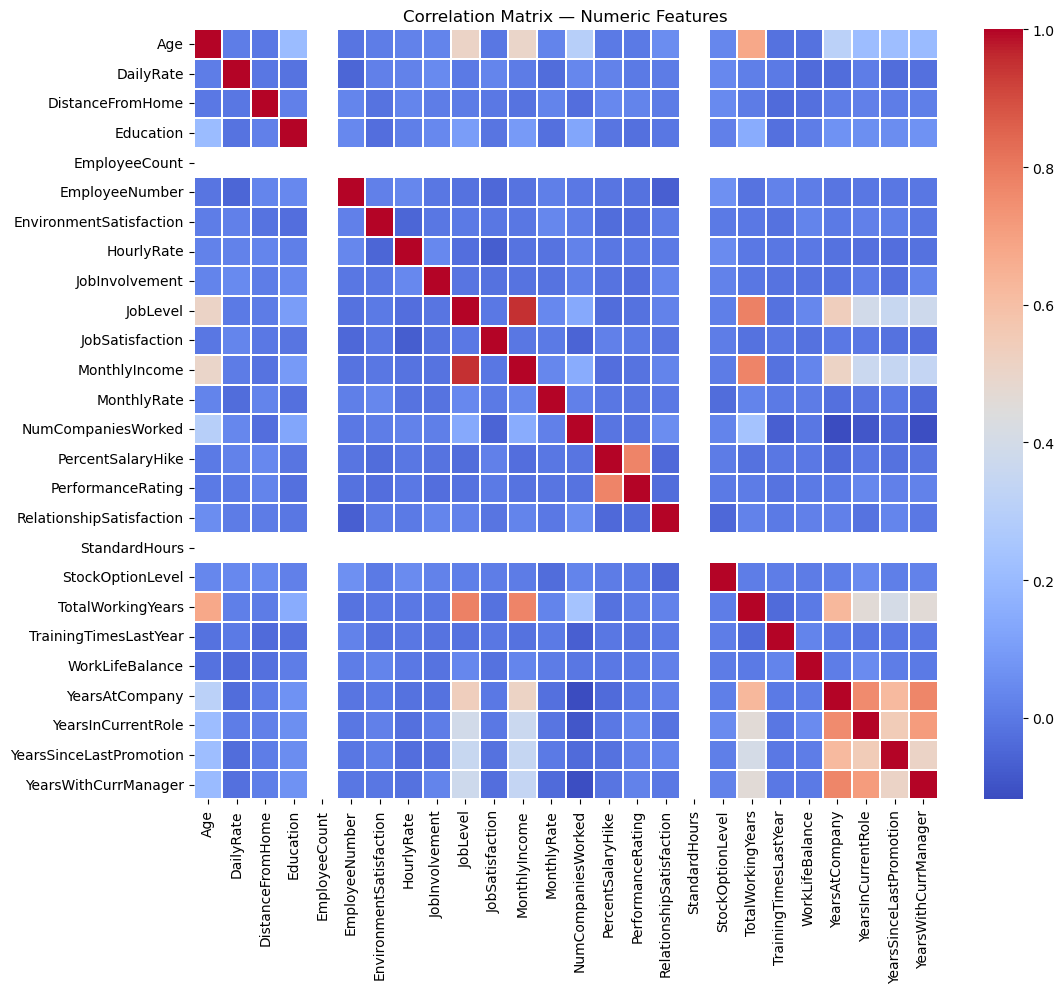

In [16]:
# Correlation heatmap (numeric)
# -----------------------------
plt.figure(figsize=(12,10))
num_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(num_df.corr(), annot=False, cmap='coolwarm', linewidths=0.2)
plt.title('Correlation Matrix — Numeric Features')
plt.show()

In [32]:
# Data cleaning / preprocessing
# -----------------------------
# 1) Drop irrelevant identifier columns if present
for col in ['EmployeeNumber','EmployeeCount','Over18','StandardHours']:
    if col in df.columns:
        df.drop(columns=col, inplace=True)


# 2) Handle missing values (simple strategy)
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print('Columns with missing values:', missing_cols)
for c in missing_cols:
    if df[c].dtype in ['float64','int64']:
        df[c].fillna(df[c].median(), inplace=True)
else:
    df[c] = df[c].fillna(df[c].mode()[0])


# 3) Encode target
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})


# 4) Label encode ordinal-like categories if any (simple approach)
le = LabelEncoder()
for c in df.select_dtypes(include=['object']).columns:
    df[c] = le.fit_transform(df[c])


print('\nAfter preprocessing — shape:', df.shape)


After preprocessing — shape: (1470, 31)


In [33]:
# Feature selection (simple correlation-based)
# -----------------------------
# Compute correlation of features with target
corr_with_target = df.corr()['Attrition'].abs().sort_values(ascending=False)
print('\nTop correlations with Attrition:')
print(corr_with_target.head(15))


# Choose top features (excluding target)
top_features = corr_with_target.index[1:16].tolist() # top 15 features
print('\nSelected features for modeling:', top_features)


X = df[top_features]
y = df['Attrition']


Top correlations with Attrition:
Attrition                  1.000000
OverTime                   0.246118
TotalWorkingYears          0.171063
JobLevel                   0.169105
MaritalStatus              0.162070
YearsInCurrentRole         0.160545
MonthlyIncome              0.159840
Age                        0.159205
YearsWithCurrManager       0.156199
StockOptionLevel           0.137145
YearsAtCompany             0.134392
JobInvolvement             0.130016
JobSatisfaction            0.103481
EnvironmentSatisfaction    0.103369
DistanceFromHome           0.077924
Name: Attrition, dtype: float64

Selected features for modeling: ['OverTime', 'TotalWorkingYears', 'JobLevel', 'MaritalStatus', 'YearsInCurrentRole', 'MonthlyIncome', 'Age', 'YearsWithCurrManager', 'StockOptionLevel', 'YearsAtCompany', 'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'DistanceFromHome', 'JobRole']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Logistic Regression — Accuracy: 0.8707482993197279
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.74      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.81      0.64      0.68       294
weighted avg       0.86      0.87      0.85       294



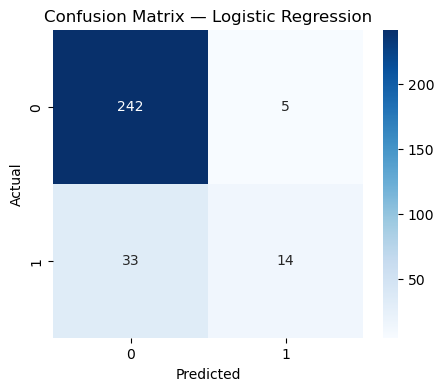

Logistic ROC AUC: 0.8041174950469464


In [35]:
# Model 1: Logistic Regression
# -----------------------------
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)


y_pred_lr = lr.predict(X_test_scaled)
print('\nLogistic Regression — Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()


# ROC AUC
if hasattr(lr, 'predict_proba'):
    y_probs_lr = lr.predict_proba(X_test_scaled)[:,1]
    print('Logistic ROC AUC:', roc_auc_score(y_test, y_probs_lr))


Random Forest — Accuracy: 0.8401360544217688
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.50      0.15      0.23        47

    accuracy                           0.84       294
   macro avg       0.68      0.56      0.57       294
weighted avg       0.80      0.84      0.80       294



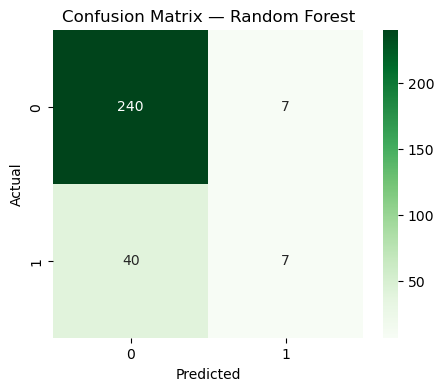


Top 10 feature importances:
MonthlyIncome              0.133095
Age                        0.115216
TotalWorkingYears          0.098387
DistanceFromHome           0.089830
YearsAtCompany             0.069821
OverTime                   0.061110
JobRole                    0.058425
YearsWithCurrManager       0.057912
EnvironmentSatisfaction    0.054296
JobSatisfaction            0.052174
dtype: float64


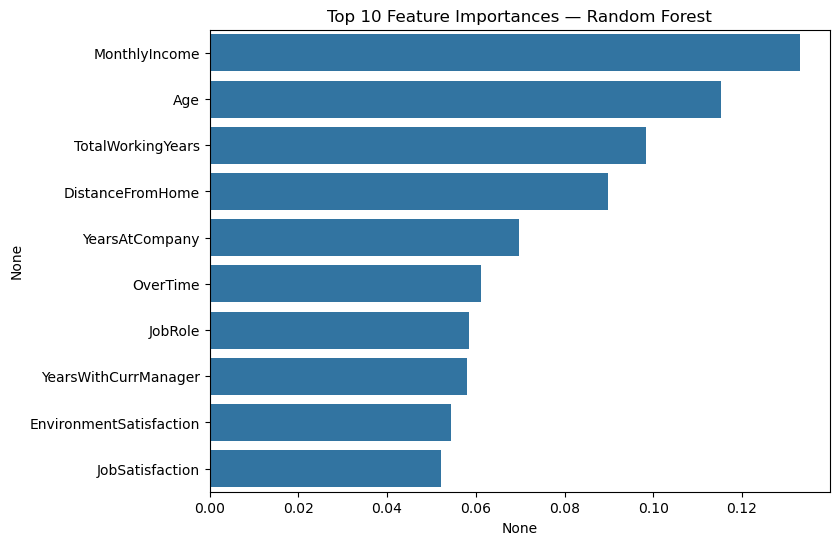

In [36]:
# Model 2: Random Forest
# -----------------------------
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
rf.fit(X_train, y_train) # RF works with unscaled input


y_pred_rf = rf.predict(X_test)
print('\nRandom Forest — Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()


# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop 10 feature importances:')
print(feat_imp.head(10))


plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.head(10), y=feat_imp.head(10).index)
plt.title('Top 10 Feature Importances — Random Forest')
plt.show()

In [24]:
# Hyperparameter tuning for Random Forest (quick grid)
# -----------------------------
param_grid = {
'n_estimators': [100, 200],
'max_depth': [None, 6, 10],
'min_samples_split': [2, 5]
}


gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
gs.fit(X_train, y_train)
print('\nGridSearch best params:', gs.best_params_)
best_rf = gs.best_estimator_


# Evaluate best_rf
y_pred_best = best_rf.predict(X_test)
print('Best RF Accuracy:', accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


GridSearch best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Accuracy: 0.8435374149659864
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.53      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.70      0.59      0.61       294
weighted avg       0.81      0.84      0.81       294



In [25]:
joblib.dump(best_rf, 'employee_attrition_rf_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print('\nSaved best model and scaler to disk.')


Saved best model and scaler to disk.


In [26]:
print('\n--- Business Summary:')
print('1) Top drivers of attrition (from feature importance):')
print(feat_imp.head(10))
print('\n2) Model performance: Use classification report above — aim to improve recall for Attrition=1 if required')
print("3) Suggested actions: Improve factors related to top features (for example: WorkLifeBalance, JobSatisfaction, OverTime etc.)")


--- Business Summary:
1) Top drivers of attrition (from feature importance):
MonthlyIncome              0.133095
Age                        0.115216
TotalWorkingYears          0.098387
DistanceFromHome           0.089830
YearsAtCompany             0.069821
OverTime                   0.061110
JobRole                    0.058425
YearsWithCurrManager       0.057912
EnvironmentSatisfaction    0.054296
JobSatisfaction            0.052174
dtype: float64

2) Model performance: Use classification report above — aim to improve recall for Attrition=1 if required
3) Suggested actions: Improve factors related to top features (for example: WorkLifeBalance, JobSatisfaction, OverTime etc.)


# Project Objective

The main objective of this project is to build a machine learning model that can predict
whether an employee is likely to leave the company. By analyzing HR factors such as job
satisfaction, income, overtime, and work–life balance, the goal is to help organizations
identify at-risk employees and take preventive actions.

# Business problem
Employee attrition is a major challenge for organizations because:
• Hiring and training new employees is expensive.
• Loss of experienced staff reduces productivity.
• Sudden exits disrupt projects and teamwork.

The business needs a predictive system that:
1. Identifies employees with high probability of attrition.
2. Highlights the factors causing attrition.
3. Helps HR design strategies for employee retention.

# Project Methodology

Steps followed in this project:


1. **Data Understanding** — Studied features such as JobRole, MonthlyIncome, WorkLifeBalance, etc.
2. **EDA (Exploratory Data Analysis)** — Visualized distributions, correlations, and patterns.
3. **Data Cleaning** — Handled missing values, removed irrelevant columns, encoded categorical features.
4. **Feature Engineering** — Selected top correlated features with Attrition.
5. **Model Building** — Logistic Regression, Random Forest, and tuned Random Forest with GridSearchCV.
6. **Evaluation** — Evaluated accuracy, recall, confusion matrix, and ROC AUC.
7. **Insights** — Identified key drivers of attrition.
8. **Deployment Prep** — Saved model using joblib for real-world usage.

# Key Insights & Conclusion

• Employees with high overtime, low job satisfaction, and lower work–life balance are more
likely to leave.
• MonthlyIncome and TotalWorkingYears strongly impact attrition.
• Random Forest performs best and captures complex interactions between HR factors.
• Improving work environment, reducing excessive overtime, and enhancing career growth
opportunities may significantly reduce attrition.


This machine learning model can be used by HR teams to predict employee risk and take
proactive actions.